In [1]:
import subprocess
import sys

print("🗑️  Uninstalling tensorflow...")
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "tensorflow"], 
               capture_output=True, timeout=60)

print("📦 Installing keras (standalone, more compatible)...")
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "keras"], 
               capture_output=True, timeout=120)

print("📦 Installing other required packages...")
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade",
                "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", 
                "beautifulsoup4", "nltk", "torch", "torchvision"], 
               capture_output=True, timeout=300)

print("✅ Installation complete!")

🗑️  Uninstalling tensorflow...
📦 Installing keras (standalone, more compatible)...
📦 Installing other required packages...
✅ Installation complete!


In [2]:
# ── Cell: Import All Libraries ──────────────────────────────────────────────────

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.neural_network import MLPClassifier

# Try to import keras
try:
    import keras
    from keras import layers
    print("✅ Keras imported successfully")
except ImportError:
    print("⚠️  Keras not available, using scikit-learn instead")
    keras = None

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("✅ All core libraries imported successfully!")
if keras:
    print(f"📦 Keras version: {keras.__version__}")
print(f"📦 Scikit-learn available for neural networks")

⚠️  Keras not available, using scikit-learn instead
✅ All core libraries imported successfully!
📦 Scikit-learn available for neural networks


In [3]:
# ── Cell 2: Load Dataset ──────────────────────────────────────────────────────
# 
# ⚠️ Change the path below to wherever your CSV file is located.
# Example: "C:/Users/YourName/Downloads/resume_dataset.csv"

df = pd.read_csv("C:data\Resume.csv")   # <── change this path

# Preview the data
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (2484, 4)

Column names: ['ID', 'Resume_str', 'Resume_html', 'Category']

First 3 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


📊 Resume count per category:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Total categories: 24

🔍 Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


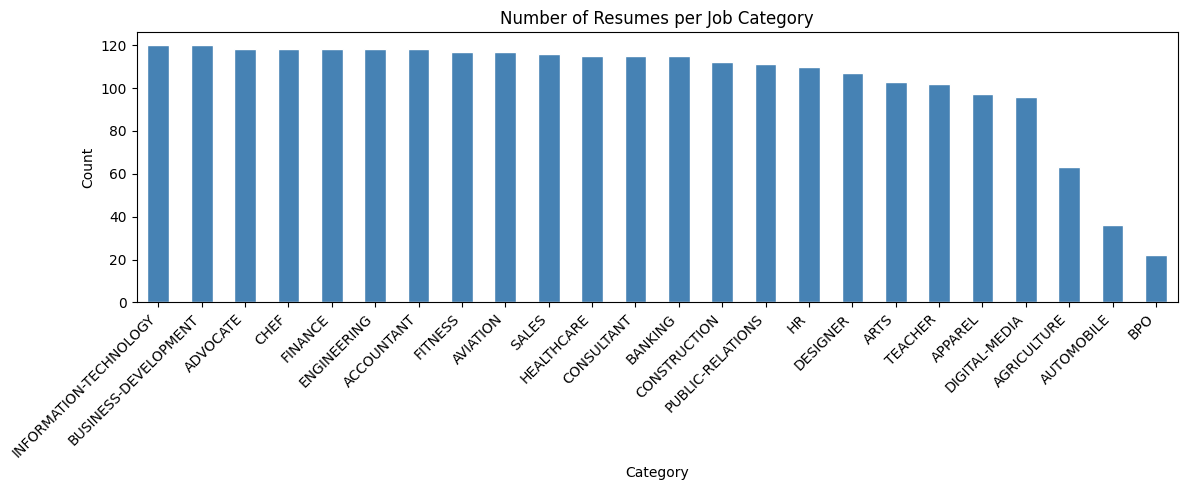

In [4]:
# ── Cell 3: Explore ───────────────────────────────────────────────────────────

# How many resumes per category?
print("📊 Resume count per category:")
print(df['Category'].value_counts())
print(f"\nTotal categories: {df['Category'].nunique()}")

# Quick check for missing values
print("\n🔍 Missing values:")
print(df.isnull().sum())

# Visualise category distribution
plt.figure(figsize=(12, 5))
df['Category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Resumes per Job Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
# ── Cell 4: Text Cleaning ─────────────────────────────────────────────────────

stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Cleans a raw resume string:
    1. Remove HTML tags (some resumes contain HTML)
    2. Remove special characters and numbers
    3. Convert to lowercase
    4. Remove stopwords
    """
    # Step 1: Remove HTML tags
    text = BeautifulSoup(str(text), "html.parser").get_text()
    
    # Step 2: Remove non-letter characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Step 3: Lowercase
    text = text.lower()
    
    # Step 4: Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    
    return ' '.join(words)

# Apply to the Resume_str column
print("🧹 Cleaning text... (this may take 10-20 seconds)")
df['clean_text'] = df['Resume_str'].apply(clean_text)

# Show before and after
print("\n✅ Done! Example:")
print("BEFORE:", df['Resume_str'].iloc[0][:200])
print("\nAFTER: ", df['clean_text'].iloc[0][:200])

🧹 Cleaning text... (this may take 10-20 seconds)

✅ Done! Example:
BEFORE:          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

AFTER:  administrator marketing associate administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams stri


In [6]:
# ── Cell 5: TF-IDF Vectorization ─────────────────────────────────────────────
#
# TF-IDF turns each resume into a row of numbers.
# Each number represents how important a word is in that resume.
# max_features=5000 → we keep only the 5000 most useful words.

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X = tfidf.fit_transform(df['clean_text']).toarray()  # shape: (2000, 5000)
y_raw = df['Category']

# Encode category labels as numbers (HR=0, IT=1, Finance=2, etc.)
le = LabelEncoder()
y = le.fit_transform(y_raw)

print(f"✅ Feature matrix shape: {X.shape}")
print(f"✅ Number of categories: {len(le.classes_)}")
print(f"   Categories: {list(le.classes_)}")

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train size: {X_train.shape[0]} resumes")
print(f"✅ Test size:  {X_test.shape[0]} resumes")

✅ Feature matrix shape: (2484, 5000)
✅ Number of categories: 24
   Categories: ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']

✅ Train size: 1987 resumes
✅ Test size:  497 resumes


In [7]:
# ── Cell 6: Build Neural Network ─────────────────────────────────────────────
#
# Using scikit-learn's MLPClassifier (Multi-Layer Perceptron)
# Architecture:
#   Input  → 5000 TF-IDF features
#   Hidden → 512 neurons, ReLU activation
#   Hidden → 256 neurons, ReLU
#   Output → N neurons (one per category)

num_classes = len(le.classes_)

# Create and train the neural network
model = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation='relu',
    solver='adam',
    max_iter=200,
    batch_size=32,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=True
)

print("🧠 Training neural network...")
model.fit(X_train, y_train)

print("\n✅ Neural network trained successfully!")

🧠 Training neural network...
Iteration 1, loss = 2.72524866
Validation score: 0.447236
Iteration 2, loss = 1.34820195
Validation score: 0.557789
Iteration 3, loss = 0.60817113
Validation score: 0.603015
Iteration 4, loss = 0.21790802
Validation score: 0.653266
Iteration 5, loss = 0.07762077
Validation score: 0.643216
Iteration 6, loss = 0.03812221
Validation score: 0.648241
Iteration 7, loss = 0.02446598
Validation score: 0.663317
Iteration 8, loss = 0.01870971
Validation score: 0.668342
Iteration 9, loss = 0.01563359
Validation score: 0.678392
Iteration 10, loss = 0.01361728
Validation score: 0.663317
Iteration 11, loss = 0.01226224
Validation score: 0.673367
Iteration 12, loss = 0.01128500
Validation score: 0.673367
Iteration 13, loss = 0.01054229
Validation score: 0.693467
Iteration 14, loss = 0.00992866
Validation score: 0.668342
Iteration 15, loss = 0.00943749
Validation score: 0.678392
Iteration 16, loss = 0.00902015
Validation score: 0.668342
Iteration 17, loss = 0.00867258
Vali

In [8]:
# ── Cell 7: Model Performance ────────────────────────────────────────────────

# Make predictions on training and test sets
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Calculate accuracies
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"📊 Training Accuracy: {train_acc:.2%}")
print(f"📊 Test Accuracy:     {test_acc:.2%}")
print(f"\n✅ Model evaluation complete!")

📊 Training Accuracy: 96.93%
📊 Test Accuracy:     67.00%

✅ Model evaluation complete!


✅ Test Accuracy: 67.00%

📊 Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.68      0.79      0.73        24
              ADVOCATE       0.50      0.62      0.56        24
           AGRICULTURE       0.50      0.54      0.52        13
               APPAREL       0.57      0.42      0.48        19
                  ARTS       0.52      0.52      0.52        21
            AUTOMOBILE       0.43      0.43      0.43         7
              AVIATION       0.89      0.71      0.79        24
               BANKING       0.73      0.70      0.71        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.68      0.79      0.73        24
                  CHEF       0.84      0.67      0.74        24
          CONSTRUCTION       0.65      0.68      0.67        22
            CONSULTANT       0.67      0.43      0.53        23
              DESIGNER       0.94      0.71      0.81

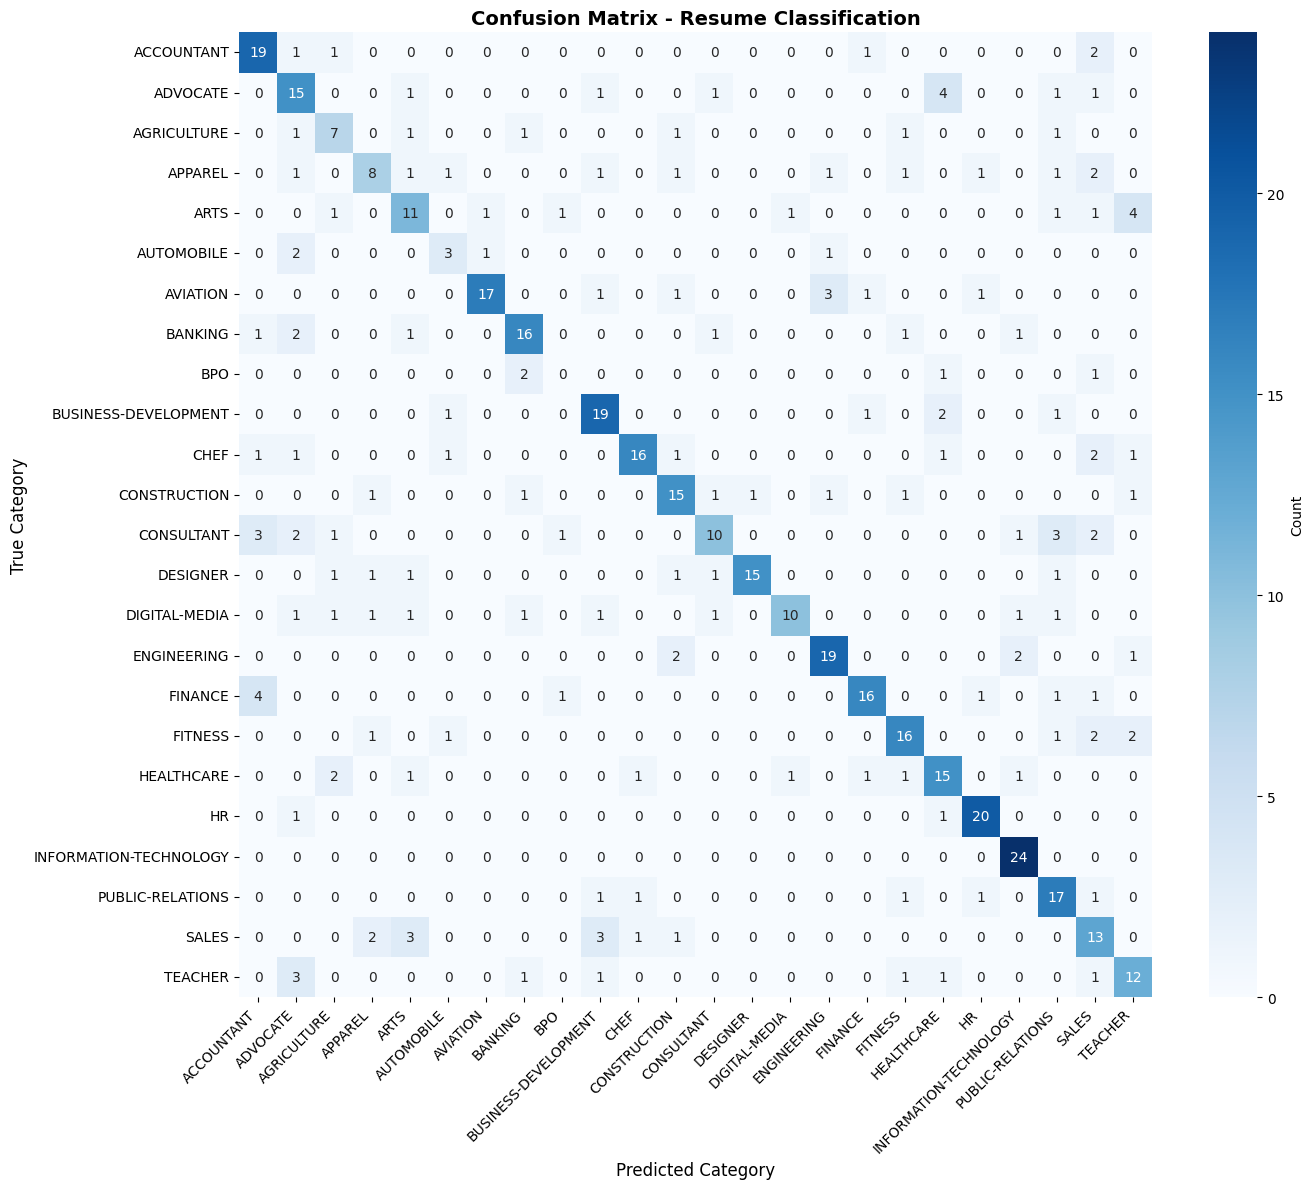


✅ Detailed evaluation complete!


In [9]:
# ── Cell 8: Evaluate ──────────────────────────────────────────────────────────

# Make predictions
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"✅ Test Accuracy: {acc:.2%}")

# --- Detailed classification report ---
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Resume Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Category', fontsize=12)
plt.xlabel('Predicted Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✅ Detailed evaluation complete!")

In [10]:
# ── Cell 9: Resume-Job Matching ───────────────────────────────────────────────
#
# Given a job description, find the top-N most matching resumes
# using cosine similarity on TF-IDF vectors.

from sklearn.metrics.pairwise import cosine_similarity

# Example job description — you can change this to any job
job_description = """
We are looking for an HR Manager with experience in recruitment, 
employee relations, payroll, benefits administration, and HRIS systems. 
Must have strong communication and leadership skills.
"""

# Clean the job description using the same function
clean_jd = clean_text(job_description)

# Vectorise the job description using the SAME tfidf fitted on resumes
jd_vector = tfidf.transform([clean_jd]).toarray()

# Compute similarity between job description and all resumes
similarities = cosine_similarity(jd_vector, X)[0]

# Get top 5 most matching resumes
top_indices = similarities.argsort()[::-1][:5]

print("🎯 Top 5 Matching Resumes for the Job Description:\n")
for rank, idx in enumerate(top_indices, 1):
    print(f"Rank {rank}:")
    print(f"  Category : {df['Category'].iloc[idx]}")
    print(f"  Similarity Score : {similarities[idx]:.4f}")
    print(f"  Resume Preview   : {df['Resume_str'].iloc[idx][:150]}...")
    print()

🎯 Top 5 Matching Resumes for the Job Description:

Rank 1:
  Category : HR
  Similarity Score : 0.2754
  Resume Preview   :          SR. HR GENERALIST       Summary    Quality-driven analytical professional who delivers consistent and successful results in HR affairs, inclu...

Rank 2:
  Category : HR
  Similarity Score : 0.2678
  Resume Preview   :          HR SHARED SERVICES ANALYST           Summary    Versatile HR professional with a strong benefits administration background, progressive cross...

Rank 3:
  Category : HR
  Similarity Score : 0.2649
  Resume Preview   :          HR GENERALIST       Professional Summary    9 years of experience in Human Resources, benefit administration, employees relations, recruitmen...

Rank 4:
  Category : HR
  Similarity Score : 0.2485
  Resume Preview   :          HR DIRECTOR       Summary     HR Professional offering over 15 years of progressive experience including extensive practice in multi-unit bus...

Rank 5:
  Category : HR
  Similarity 

🔑 Top keywords from Resume #1:
   marketing                       score: 0.2544
   dec                             score: 0.1838
   medical                         score: 0.1827
   customer                        score: 0.1787
   relations                       score: 0.1701
   medical billing                 score: 0.1525
   customer service                score: 0.1477
   billing                         score: 0.1413
   terminology                     score: 0.131
   dec company                     score: 0.1302
   employee                        score: 0.1291
   administrator                   score: 0.1255
   service                         score: 0.1212
   advertising                     score: 0.1184
   benefits                        score: 0.117


🔑 Top 10 keywords per job category:

📂 ACCOUNTANT:
   accounting | financial | accountant | accounts | tax | ledger | general ledger | payroll | statements | monthly

📂 ADVOCATE:
   customer | advocate | state | city | city state | ca

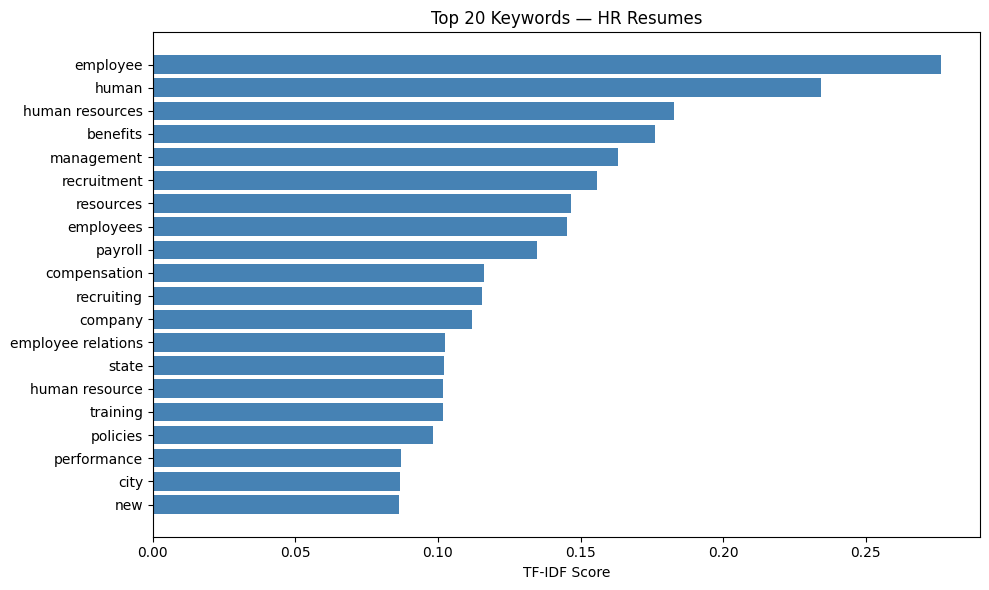

In [11]:
# ── Cell 10: Keyword Extraction ───────────────────────────────────────────────
#
# Extract the top keywords from:
#   (a) A single resume
#   (b) All resumes of a given category

feature_names = tfidf.get_feature_names_out()

def get_top_keywords(text, n=15):
    """Return the top n keywords from a single text using TF-IDF scores."""
    vec = tfidf.transform([text]).toarray()[0]
    top_idx = vec.argsort()[::-1][:n]
    return [(feature_names[i], round(vec[i], 4)) for i in top_idx if vec[i] > 0]

# ── (a) Keywords from a single resume ──
print("🔑 Top keywords from Resume #1:")
keywords = get_top_keywords(df['clean_text'].iloc[0])
for word, score in keywords:
    print(f"   {word:30s}  score: {score}")

# ── (b) Keywords for each category ──
print("\n\n🔑 Top 10 keywords per job category:\n")
for category in le.classes_:
    cat_texts = df[df['Category'] == category]['clean_text'].tolist()
    combined = ' '.join(cat_texts)
    kws = get_top_keywords(combined, n=10)
    print(f"📂 {category}:")
    print("   " + " | ".join([w for w, _ in kws]))
    print()

# ── Visualise keywords for one category ──
target_category = "HR"   # change to any category in your dataset

cat_texts = df[df['Category'] == target_category]['clean_text'].tolist()
kws = get_top_keywords(' '.join(cat_texts), n=20)
words, scores = zip(*kws)

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], scores[::-1], color='steelblue')
plt.title(f'Top 20 Keywords — {target_category} Resumes')
plt.xlabel('TF-IDF Score')
plt.tight_layout()
plt.show()